# 06 — Physics setup for SINN

## Objectif

Définir le problème physique bidimensionnel de sloshing eau–air, sans utiliser de données CFD pour l'entraînement.

Le modèle doit permettre à terme de prédire :

- les champs de vitesse \(u(x,y,t)\) et \(v(x,y,t)\) ;
- la pression physique \(p(x,y,t)\) ;
- la fraction volumique d'eau \(\alpha(x,y,t)\) ;
- les forces \(F_x,F_y\) et le moment \(M_z\) exercés par le fluide sur le réservoir ;
- le mouvement du réservoir lorsqu'il est mécaniquement libre.

Deux configurations sont visées :

1. Réservoir à mouvement imposé.
2. Réservoir libre, éventuellement relié à un support masse–ressort–amortisseur.

Les données CFD sont réservées à une validation indépendante après entraînement.

Ce notebook définit la géométrie, les propriétés physiques, les conditions initiales, les conditions aux limites et les points de collocation utilisés pour l'apprentissage physique.

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Répertoire de configuration :", DATA_DIR.resolve())

Répertoire de configuration : /home/ludodo/SINN/data


In [2]:
# Géométrie 2D — valeurs provisoires à remplacer
L = 1.0             # longueur du réservoir [m]
H = 0.5             # hauteur du réservoir [m]
h0 = 0.25           # hauteur initiale d'eau [m]

# Gravité
g = 9.81            # [m/s²]

# Eau
rho_water = 1000.0  # [kg/m³]
mu_water = 1.0e-3   # [Pa.s]

# Air
rho_air = 1.2       # [kg/m³]
mu_air = 1.8e-5     # [Pa.s]

# Tension superficielle eau-air
sigma = 0.072       # [N/m], valeur indicative

# Temps de simulation
T_end = 2.0         # [s]
N_time = 201

# Résolution de collocation
N_interior = 20_000
N_boundary = 4_000
N_initial = 4_000

assert L > 0 and H > 0
assert 0 < h0 < H
assert T_end > 0
assert rho_water > rho_air > 0
assert mu_water > 0 and mu_air > 0
assert sigma >= 0

time_grid = np.linspace(0.0, T_end, N_time)
dt_nominal = time_grid[1] - time_grid[0]

print(f"dt nominal = {dt_nominal:.5g} s")
print(f"Rapport de remplissage h0/H = {h0/H:.3f}")

dt nominal = 0.01 s
Rapport de remplissage h0/H = 0.500


Le modèle utilisera une formulation de type VOF à propriétés variables, avec :
\[
\mathbf u=(u,v),\qquad
\rho(\alpha)=\alpha\rho_w+(1-\alpha)\rho_a
\]

\[
\mu(\alpha)=\alpha\mu_w+(1-\alpha)\mu_a
\]

La conservation de masse pour un mélange incompressible est :
\[
\nabla\cdot\mathbf u=0
\]

Le transport de la fraction volumique est formulé sous la forme :
\[
\frac{\partial\alpha}{\partial t}
+\nabla\cdot(\alpha\mathbf u)=0
\]

La quantité de mouvement s'écrit :
\[
\frac{\partial(\rho\mathbf u)}{\partial t}
+\nabla\cdot(\rho\mathbf u\otimes\mathbf u)
=
-\nabla p+\nabla\cdot\boldsymbol\tau
+\rho\mathbf g+\mathbf f_\sigma
\]

Cette formulation est un point de départ continu. Il faudra définir précisément le modèle de tension superficielle et les contraintes visqueuses, et vérifier leur cohérence avec le cas interFoam. La compression d'interface utilisée par certaines formulations VOF n'est pas automatiquement représentée par l'équation de transport simplifiée.
La difficulté des PINNs en mécanique des fluides est notamment de concilier les résidus des équations, les conditions aux limites et les différentes échelles physiques. Une revue générale des PINNs en mécanique des fluides discute ces enjeux : Physics-informed neural networks (PINNs) for fluid mechanics: a review. 

Springer Nature Link

MOTION_MODE = "prescribed"  # "prescribed" ou "free"

# Excitation provisoire pour le cas prescrit
A_EXC = 0.02       # amplitude du déplacement [m]
F_EXC = 1.0        # fréquence [Hz]
PHASE_EXC = 0.0    # phase [rad]

OMEGA_EXC = 2.0 * np.pi * F_EXC

def tank_position(t):
    """Déplacement horizontal imposé du réservoir [m]."""
    return A_EXC * np.sin(OMEGA_EXC * t + PHASE_EXC)

def tank_velocity(t):
    """Vitesse horizontale imposée [m/s]."""
    return A_EXC * OMEGA_EXC * np.cos(
        OMEGA_EXC * t + PHASE_EXC
    )

def tank_acceleration(t):
    """Accélération horizontale imposée [m/s²]."""
    return -A_EXC * OMEGA_EXC**2 * np.sin(
        OMEGA_EXC * t + PHASE_EXC
    )

if MOTION_MODE not in ("prescribed", "free"):
    raise ValueError("MOTION_MODE doit être 'prescribed' ou 'free'.")

if MOTION_MODE == "prescribed":
    print("Le mouvement sera imposé par une loi temporelle.")
else:
    print("Le mouvement devra être résolu par le couplage mécanique.")

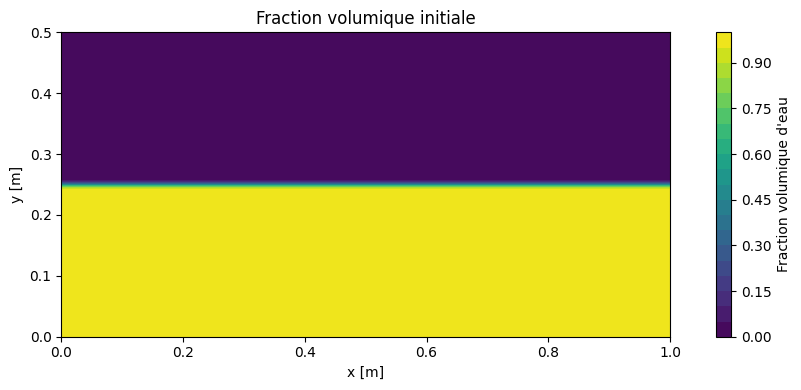

In [3]:
INTERFACE_WIDTH = 0.005  # [m], largeur de transition numérique

def alpha_initial(x, y):
    """
    Fraction volumique initiale d'eau.
    x et y peuvent être des tableaux NumPy.
    """
    return 0.5 * (
        1.0 - np.tanh((y - h0) / INTERFACE_WIDTH)
    )

# Grille pour visualiser l'état initial
nx, ny = 300, 160
x_plot = np.linspace(0.0, L, nx)
y_plot = np.linspace(0.0, H, ny)
XX, YY = np.meshgrid(x_plot, y_plot)

ALPHA0 = alpha_initial(XX, YY)

fig, ax = plt.subplots(figsize=(10, 4))
contour = ax.contourf(
    XX, YY, ALPHA0,
    levels=np.linspace(0, 1, 21),
)
fig.colorbar(contour, ax=ax, label="Fraction volumique d'eau")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Fraction volumique initiale")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [4]:
x_int = rng.uniform(0.0, L, N_interior)
y_int = rng.uniform(0.0, H, N_interior)
t_int = rng.uniform(0.0, T_end, N_interior)

points_interior = np.column_stack([
    x_int, y_int, t_int
]).astype(np.float32)

print("Points intérieurs :", points_interior.shape)

Points intérieurs : (20000, 3)


In [5]:
def sample_boundary(n, rng):
    n_side = n // 4
    t = rng.uniform(0.0, T_end, n_side)

    left = np.column_stack([
        np.zeros(n_side),
        rng.uniform(0.0, H, n_side),
        t
    ])

    right = np.column_stack([
        np.full(n_side, L),
        rng.uniform(0.0, H, n_side),
        t
    ])

    bottom = np.column_stack([
        rng.uniform(0.0, L, n_side),
        np.zeros(n_side),
        rng.uniform(0.0, T_end, n_side)
    ])

    top = np.column_stack([
        rng.uniform(0.0, L, n_side),
        np.full(n_side, H),
        rng.uniform(0.0, T_end, n_side)
    ])

    return {
        "left": left.astype(np.float32),
        "right": right.astype(np.float32),
        "bottom": bottom.astype(np.float32),
        "top": top.astype(np.float32),
    }

boundary_points = sample_boundary(N_boundary, rng)

for name, pts in boundary_points.items():
    print(f"{name:>6} : {pts.shape}")

  left : (1000, 3)
 right : (1000, 3)
bottom : (1000, 3)
   top : (1000, 3)


In [6]:
x0 = rng.uniform(0.0, L, N_initial)
y0 = rng.uniform(0.0, H, N_initial)
t0 = np.zeros(N_initial)

points_initial = np.column_stack([
    x0, y0, t0
]).astype(np.float32)

alpha0_targets = alpha_initial(x0, y0).astype(np.float32)

# État de repos initial, dans le référentiel du réservoir
u0_targets = np.zeros(N_initial, dtype=np.float32)
v0_targets = np.zeros(N_initial, dtype=np.float32)

print("Points initiaux :", points_initial.shape)
print("Cibles alpha :", alpha0_targets.shape)

Points initiaux : (4000, 3)
Cibles alpha : (4000,)


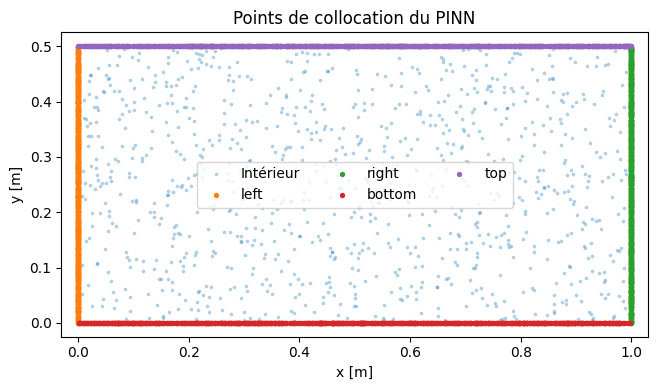

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(
    points_interior[::20, 0],
    points_interior[::20, 1],
    s=3,
    alpha=0.25,
    label="Intérieur",
)

for name, pts in boundary_points.items():
    ax.scatter(pts[:, 0], pts[:, 1], s=8, label=name)

ax.set_xlim(-0.03 * L, 1.03 * L)
ax.set_ylim(-0.05 * H, 1.05 * H)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Points de collocation du PINN")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

In [8]:
config = {
    "dimension": 2,
    "model": "VOF_variable_properties",
    "motion_mode": MOTION_MODE,
    "geometry": {
        "L": L,
        "H": H,
        "h0": h0,
    },
    "fluid": {
        "rho_water": rho_water,
        "mu_water": mu_water,
        "rho_air": rho_air,
        "mu_air": mu_air,
        "sigma": sigma,
    },
    "gravity": {
        "g": g,
    },
    "time": {
        "T_end": T_end,
        "N_time": N_time,
        "dt_nominal": dt_nominal,
    },
    "initial_condition": {
        "interface_width": INTERFACE_WIDTH,
        "initial_velocity": "zero",
    },
    "excitation": {
        "amplitude": A_EXC,
        "frequency": F_EXC,
        "phase": PHASE_EXC,
    },
    "collocation": {
        "N_interior": N_interior,
        "N_boundary": N_boundary,
        "N_initial": N_initial,
    },
    "training_data": None,
}

with open(DATA_DIR / "sinn_physics_config.json", "w") as f:
    json.dump(config, f, indent=2)

np.savez_compressed(
    DATA_DIR / "sinn_collocation_points.npz",
    interior=points_interior,
    initial=points_initial,
    alpha_initial=alpha0_targets,
    u_initial=u0_targets,
    v_initial=v0_targets,
    boundary_left=boundary_points["left"],
    boundary_right=boundary_points["right"],
    boundary_bottom=boundary_points["bottom"],
    boundary_top=boundary_points["top"],
    time_grid=time_grid,
)

print("Configuration physique enregistrée.")
print("Aucune donnée CFD utilisée.")

NameError: name 'MOTION_MODE' is not defined